<a href="https://colab.research.google.com/github/sakshamnegi9-web/firstgit-demo/blob/main/chrn_git.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Generating Insights for Model Feature Selection ---


<Figure size 1000x600 with 0 Axes>

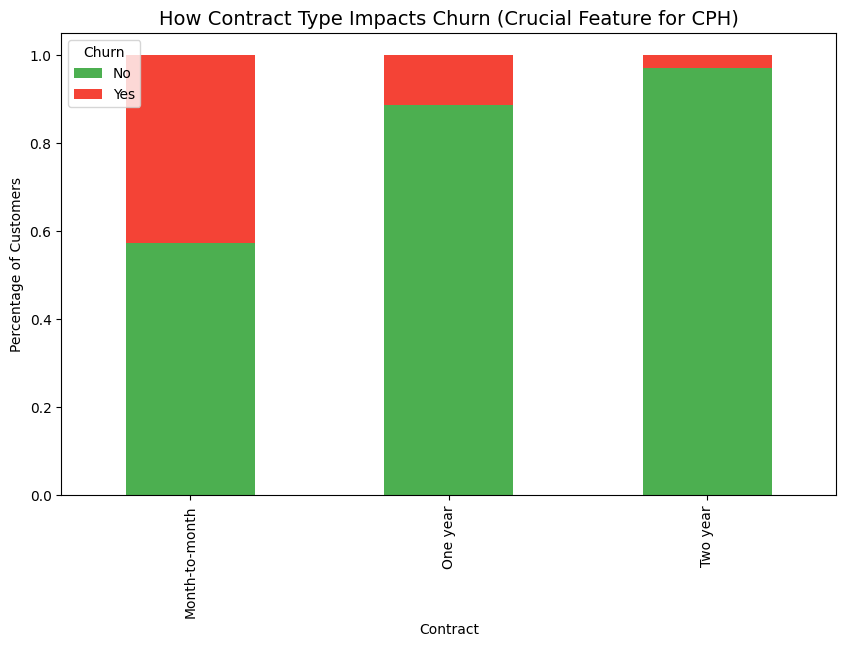

/tmp/ipykernel_182/4091583725.py:42: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Churn'] == 'No', 'tenure'], label='Loyal Customers', shade=True, color='blue')
/tmp/ipykernel_182/4091583725.py:43: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Churn'] == 'Yes', 'tenure'], label='Exited Customers', shade=True, color='orange')


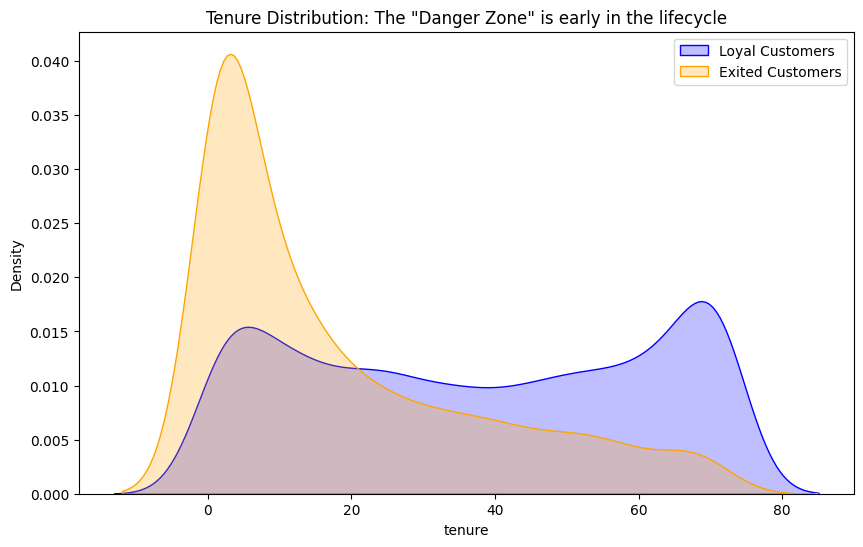

--- Calculating Shifting Risk Milestones (Recursive Logic) ---


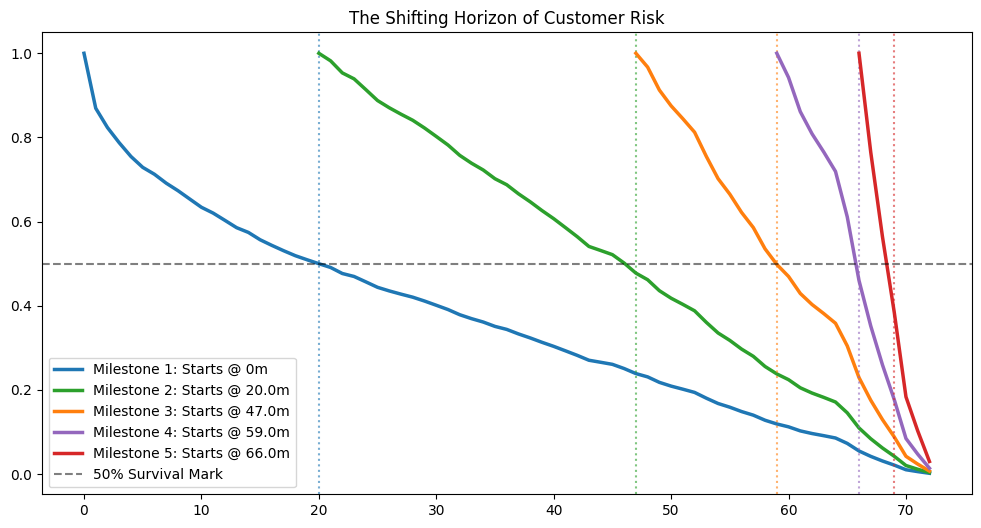


--- SAMPLE REPORT: FIRST 10 CUSTOMERS ---
CustomerID Actual_Churn  Current_Month  Median_Risk_Month  Remaining_Tenure
7590-VHVEG           No              1               20.0              19.0
5575-GNVDE           No             34                inf               inf
3668-QPYBK          Yes              2               49.0              47.0
7795-CFOCW           No             45                inf               inf
9237-HQITU          Yes              2               14.0              12.0
9305-CDSKC          Yes              8               46.0              38.0
1452-KIOVK           No             22               33.0              11.0
6713-OKOMC           No             10               20.0              10.0
7892-POOKP          Yes             28               52.0              24.0
6388-TABGU           No             62                inf               inf

--- ACTION PLAN: TOP 10 OVERDUE CUSTOMERS (URGENT RETENTION) ---
CustomerID Actual_Churn  Current_Month  Median_Risk_Mon

In [11]:
# -*- coding: utf-8 -*-
"""
TELCO CUSTOMER CHURN: PREDICTIVE SURVIVAL MODELING
Author: Saksham
Context: MBA Analytics & Data Science Portfolio

REASONING:
Standard churn models tell us IF a customer will leave. This project uses
Survival Analysis to answer WHEN. By identifying 'Median Risk Months,'
we can create a proactive retention schedule for the marketing team.
"""

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter

# --- 1. DATA LOADING & CLEANING ---
# Using the standard Telco dataset from Kaggle
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# TotalCharges has empty strings that cause errors; converting to numeric
# and filling with 0 to ensure the model runs smoothly.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_Binary'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---
# I performed EDA to validate which variables should be included in the model.
print("--- Generating Insights for Model Feature Selection ---")

# Insight 1: Month-to-month contracts are the highest churn drivers.
plt.figure(figsize=(10, 6))
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn_pct = (contract_churn.T / contract_churn.T.sum()).T
contract_churn_pct.plot(kind='bar', stacked=True, color=['#4CAF50', '#F44336'], figsize=(10,6))
plt.title('How Contract Type Impacts Churn (Crucial Feature for CPH)', fontsize=14)
plt.ylabel('Percentage of Customers')
plt.show()

# Insight 2: Churn is heavily concentrated in the first 12 months.
plt.figure(figsize=(10, 6))
sns.kdeplot(df.loc[df['Churn'] == 'No', 'tenure'], label='Loyal Customers', shade=True, color='blue')
sns.kdeplot(df.loc[df['Churn'] == 'Yes', 'tenure'], label='Exited Customers', shade=True, color='orange')
plt.title('Tenure Distribution: The "Danger Zone" is early in the lifecycle')
plt.legend()
plt.show()

# --- 3. SURVIVAL MODEL TRAINING ---
# I selected these features because they represent the "Financial" and "Commitment"
# aspects of the customer relationship.
features = ['tenure', 'Churn_Binary', 'MonthlyCharges', 'Contract', 'InternetService']
df_model = pd.get_dummies(df[features], drop_first=True)

# Training the Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(df_model, duration_col='tenure', event_col='Churn_Binary')

# --- 4. THE RECURSIVE SURVIVAL CHAIN (The "Saksham Milestone" Logic) ---
# This specific logic tracks how the 50% risk threshold moves forward as
# a customer stays longer. It's a "resetting" risk milestone.
customer = df_model.iloc[0:1]
base_surv = cph.predict_survival_function(customer)

plt.figure(figsize=(12, 6))
current_start = 0
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#d62728']

print("--- Calculating Shifting Risk Milestones (Recursive Logic) ---")
for i in range(len(colors)):
    prob_at_start = base_surv.loc[current_start].iloc[0]
    cond_surv = base_surv / prob_at_start
    cond_surv = cond_surv.loc[cond_surv.index >= current_start]

    try:
        next_median = cond_surv[cond_surv.iloc[:, 0] <= 0.5].index.min()
        if pd.isna(next_median): break

        plt.plot(cond_surv, color=colors[i], linewidth=2.5, label=f'Milestone {i+1}: Starts @ {current_start}m')
        plt.axvline(x=next_median, color=colors[i], linestyle=':', alpha=0.6)
        current_start = next_median
    except:
        break

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='50% Survival Mark')
plt.title('The Shifting Horizon of Customer Risk')
plt.legend()
plt.show()

# --- 5. RISK PREDICTION & BUSINESS REPORTING ---
# Here we calculate exactly how many months each customer has left until
# they cross the 50% churn probability threshold.
predictions = cph.predict_median(df_model)

results_df = pd.DataFrame({
    'CustomerID': df['customerID'],
    'Actual_Churn': df['Churn'],
    'Current_Month': df['tenure'],
    'Median_Risk_Month': predictions.values,
})

# BUSINESS LOGIC: If Remaining_Tenure is negative, the customer is "Borrowed Time".
# They have already passed their 50% risk point and are top priority for retention.
results_df['Remaining_Tenure'] = results_df['Median_Risk_Month'] - results_df['Current_Month']

# A. Overview of First 10 Customers
print("\n--- SAMPLE REPORT: FIRST 10 CUSTOMERS ---")
print(results_df.head(10).to_string(index=False))

# B. Priority List: Most Overdue (High Risk)
print("\n--- ACTION PLAN: TOP 10 OVERDUE CUSTOMERS (URGENT RETENTION) ---")
# These customers are statistically "past due" for churning.
high_risk = results_df.sort_values(by='Remaining_Tenure').head(10)
print(high_risk.to_string(index=False))